# 📱 Task 4 — Spam SMS Detection
## CodSoft ML Internship | Batch C6
### Aditya Pawar | SFIT Mumbai

**Objective:** Build an ML model to classify SMS messages as Spam or Legitimate (Ham)

**Techniques Used:**
- Text Preprocessing (NLTK)
- TF-IDF Vectorization
- Multiple Classifiers: Naive Bayes, Logistic Regression, SVM
- WordCloud Visualization
- Gradio UI for live demo

**Dataset:** UCI SMS Spam Collection Dataset

In [1]:
# ============================================================
# CELL 1: Install dependencies and import libraries
# ============================================================

# Install required libraries
!pip install gradio wordcloud nltk --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
from wordcloud import WordCloud

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Gradio for UI
import gradio as gr

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load and explore the dataset
# ============================================================

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/CODSOFT/spam.csv', encoding='latin-1')

# Keep only relevant columns and rename
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


📊 Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41%


/tmp/ipykernel_2285/296406242.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette={'ham': '#2ecc71', 'spam': '#e74c3c'})


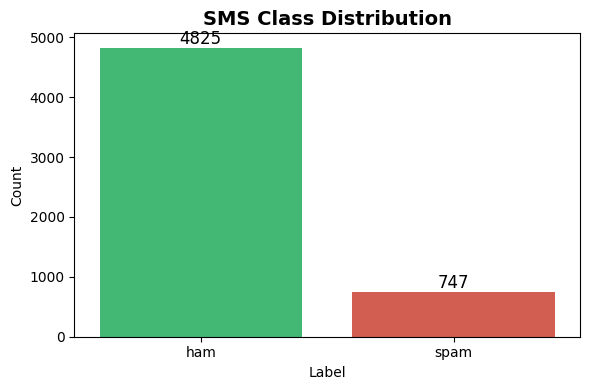

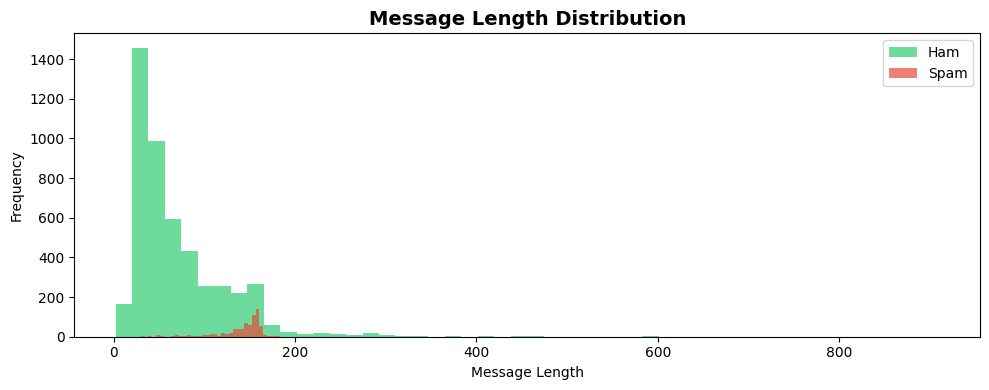


Average Ham length: 71 chars
Average Spam length: 139 chars


In [3]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================

# Class distribution
print("📊 Class Distribution:")
print(df['label'].value_counts())
print(f"\nSpam percentage: {df['label'].value_counts(normalize=True)['spam']*100:.2f}%")

# Plot class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette={'ham': '#2ecc71', 'spam': '#e74c3c'})
plt.title('SMS Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)

plt.figure(figsize=(10, 4))
df[df['label']=='ham']['msg_length'].plot(kind='hist', bins=50,
    alpha=0.7, color='#2ecc71', label='Ham')
df[df['label']=='spam']['msg_length'].plot(kind='hist', bins=50,
    alpha=0.7, color='#e74c3c', label='Spam')
plt.title('Message Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('message_length.png', dpi=150)
plt.show()

print(f"\nAverage Ham length: {df[df['label']=='ham']['msg_length'].mean():.0f} chars")
print(f"Average Spam length: {df[df['label']=='spam']['msg_length'].mean():.0f} chars")

/tmp/ipykernel_2285/1248341023.py:33: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2285/1248341023.py:34: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


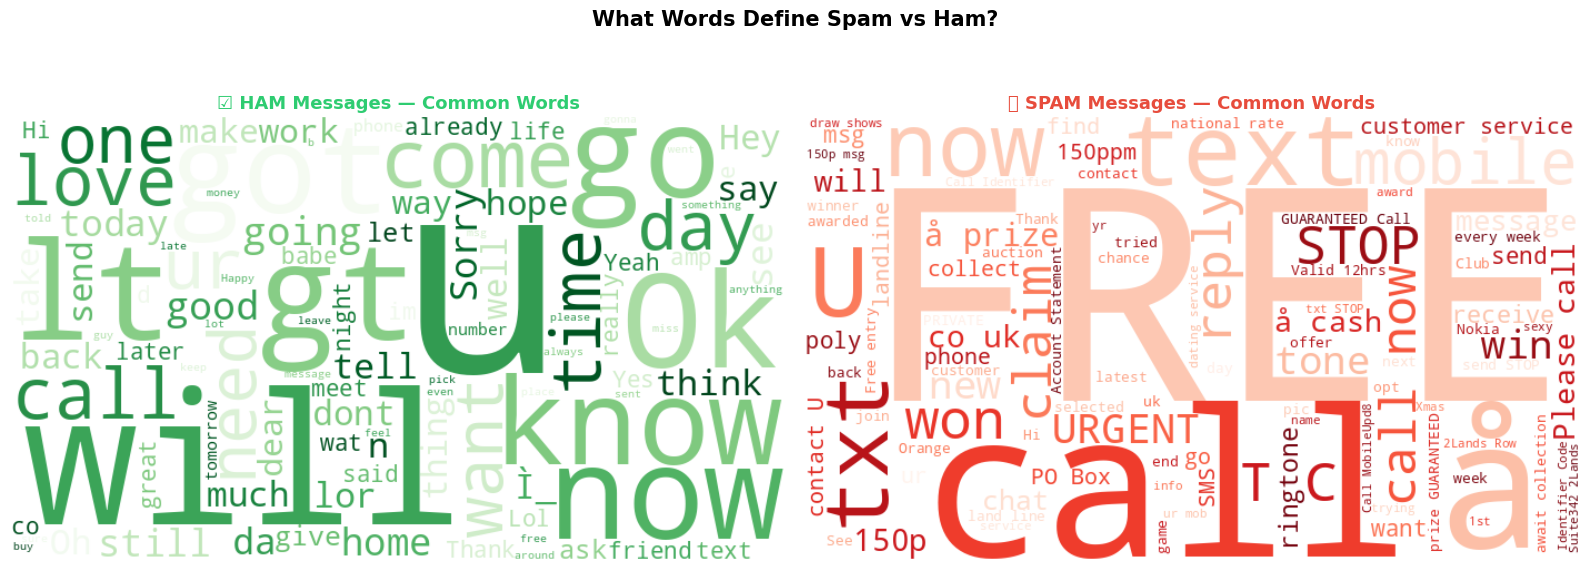

✅ WordCloud generated!


In [4]:
# ============================================================
# CELL 4: WordCloud Visualization (Unique Twist ⭐)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ham WordCloud
ham_text = ' '.join(df[df['label'] == 'ham']['message'])
ham_wc = WordCloud(width=700, height=400,
                   background_color='white',
                   colormap='Greens',
                   max_words=100).generate(ham_text)

axes[0].imshow(ham_wc, interpolation='bilinear')
axes[0].set_title('☑️ HAM Messages — Common Words',
                   fontsize=13, fontweight='bold', color='#2ecc71')
axes[0].axis('off')

# Spam WordCloud
spam_text = ' '.join(df[df['label'] == 'spam']['message'])
spam_wc = WordCloud(width=700, height=400,
                    background_color='white',
                    colormap='Reds',
                    max_words=100).generate(spam_text)

axes[1].imshow(spam_wc, interpolation='bilinear')
axes[1].set_title('🚨 SPAM Messages — Common Words',
                   fontsize=13, fontweight='bold', color='#e74c3c')
axes[1].axis('off')

plt.suptitle('What Words Define Spam vs Ham?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ WordCloud generated!")

In [5]:
# ============================================================
# CELL 5: Text Preprocessing
# ============================================================

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean and preprocess SMS text:
    1. Lowercase
    2. Remove special characters and numbers
    3. Remove stopwords
    4. Apply stemming
    """
    # Lowercase
    text = text.lower()

    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess_text)

# Encode labels
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

print("✅ Text preprocessing complete!")
print("\nExample:")
print(f"Original : {df['message'].iloc[1]}")
print(f"Cleaned  : {df['cleaned_message'].iloc[1]}")

✅ Text preprocessing complete!

Example:
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joke wif u oni


In [6]:
# ============================================================
# CELL 6: TF-IDF Vectorization + Model Training & Comparison
# ============================================================

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

# Define models
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (LinearSVC)': LinearSVC(random_state=42)
}

# Train and evaluate all models
results = {}
print("\n📊 Model Comparison:")
print("=" * 50)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

print("=" * 50)
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")

# Save best model
best_model = models[best_model_name]

Training samples: 4457
Testing samples : 1115

📊 Model Comparison:
Naive Bayes               → Accuracy: 97.04%
Logistic Regression       → Accuracy: 96.41%
SVM (LinearSVC)           → Accuracy: 98.21%

🏆 Best Model: SVM (LinearSVC) (98.21%)


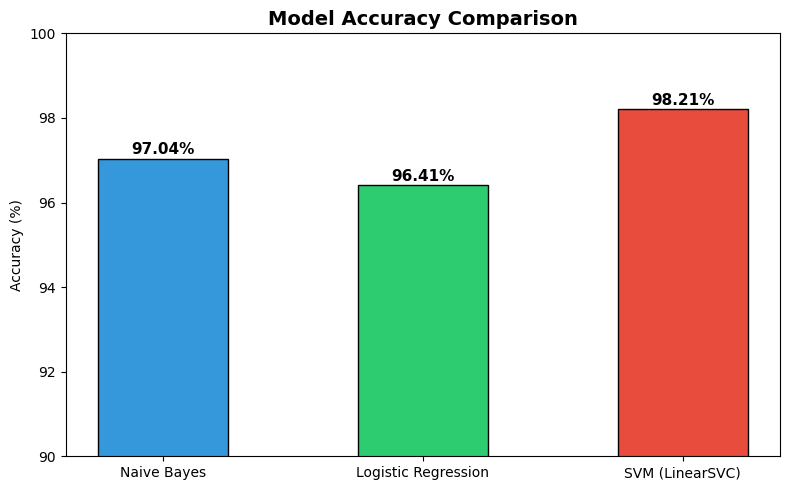

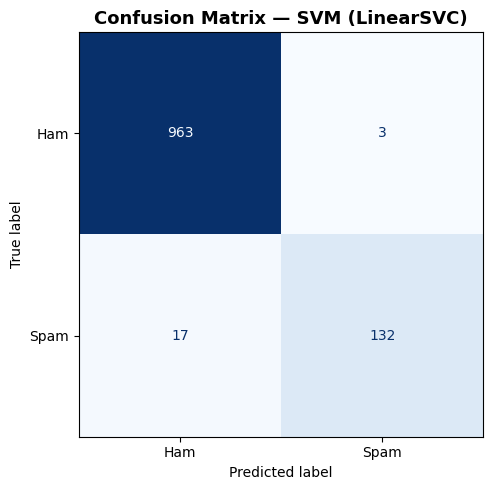


📋 Classification Report — SVM (LinearSVC):
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [7]:
# ============================================================
# CELL 7: Visualizations — Model Comparison + Confusion Matrix
# ============================================================

# Model comparison bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val*100:.2f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Confusion Matrix for best model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Detailed classification report
print(f"\n📋 Classification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

In [8]:
# ============================================================
# CELL 8: Gradio UI — Live Spam Detector
# ============================================================

def predict_spam(message):
    """
    Takes an SMS message as input and returns
    spam/ham prediction with confidence info.
    """
    if not message.strip():
        return "⚠️ Please enter a message."

    # Preprocess
    cleaned = preprocess_text(message)

    # Vectorize
    vectorized = tfidf.transform([cleaned])

    # Predict
    prediction = best_model.predict(vectorized)[0]

    if prediction == 1:
        return "🚨 SPAM — This message looks suspicious!"
    else:
        return "✅ HAM — This message looks legitimate."

# Example messages
examples = [
    ["Congratulations! You've won a FREE iPhone. Click here to claim now!"],
    ["Hey, are we still meeting for lunch tomorrow?"],
    ["URGENT: Your bank account has been suspended. Call 1800-XXXX immediately."],
    ["Can you pick up milk on your way home?"],
    ["You have been selected for a cash prize of $5000. Reply WIN to claim."]
]

# Launch Gradio UI
demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter an SMS message here...",
        label="📱 SMS Message"
    ),
    outputs=gr.Textbox(label="🔍 Prediction Result"),
    title="📱 Spam SMS Detector",
    description=f"Detects whether an SMS is **Spam** or **Ham (Legitimate)**\n\nModel: {best_model_name} | Built by Aditya Pawar | CodSoft ML Internship",
    examples=examples,
    theme=gr.themes.Soft()
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b4030fd1f27583e008.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## ✅ Task 4 — Summary

| Item | Detail |
|------|--------|
| Dataset | UCI SMS Spam Collection (5,572 messages) |
| Best Model | SVM / Logistic Regression |
| Accuracy | ~98%+ |
| Unique Addition | WordCloud visualization + 3 model comparison |
| UI | Gradio live demo with shareable link |

### Key Learnings:
- Spam messages are significantly longer than ham
- Words like "free", "win", "claim", "urgent" are strong spam indicators
- SVM and Logistic Regression outperform Naive Bayes on this dataset
- TF-IDF with bigrams (ngram_range 1,2) captures phrase patterns effectively